# Estimating cosmological parameters and selecting cosmological models with SNIa data

We find best-fit parameters and select the best cosmological model using the [Supernova Cosmology Project](http://supernova.lbl.gov/union/) data. These consist of measurements of the distance modulus of 580 Supernovae Ia, an excellent standard candle:

$$\mu = m_B-M_B$$

with $m_B$ apparent magnitude and $M_B$ absolute magnitude in some band (e.g. the blue band, $B$). The absolute magnitude is inferred from the shape of $m_B(t)$.

The distance modulus can be related in turn to the luminosity distance, which is a function of the redshift $z$ of the source:

$$\mu(z, \boldsymbol{\theta})=5 \log_{10} \dfrac{d_{L}(z, \boldsymbol{\theta})}{\text{Mpc}}+25$$

with $d_L$ luminosity distance of the source. In the *flat* Standard Cosmological model LCDM, this is given by

$$d_{L}\left(z; h, \Omega_{m}\right)=\dfrac{c}{100\dfrac{\text{s*Mpc}}{\text{Km}} h}(1+z)
\int_{0}^{z} \frac{\mathrm{d} z^{\prime}}{\sqrt{\Omega_{m}\left(1+z^{\prime}\right)^{3}+(1-\Omega_{m})}}$$

with $h$ is the dimensionless Hubble constant and $\Omega_{m}$ the density parameter of matter. In this model Dark Energy (DE) is interpreted as a constant term ($\Lambda$) in Einstein's field equations of General Relativity.
A simple generalization of this model is to consider DE as a perfect fluid with equation of state $p=w_0\rho$, with $w_0$ the equation of state parameter (wCDM). It reduces to LCDM for $w_0 = -1$ = const. In this model the luminosity distance is

$$d_{L}\left(z; h, \Omega_{m}, w_0\right)=\dfrac{c}{100\dfrac{\text{s*Mpc}}{\text{Km}} h}(1+z)
\int_{0}^{z} \frac{\mathrm{d} z^{\prime}}{\sqrt{\Omega_{m}\left(1+z^{\prime}\right)^{3}+(1-\Omega_{m})\left(1+z^{\prime}\right)^{3(1+w_0)}}}$$

To sum up, in this excercise we'll use two models:
1.  flat LCDM model: $w_0=-1=\rm{const}$,  $\quad\boldsymbol{\theta}=(h, \Omega_{m})$
2.  flat wCDM model: variable $w_0$, $\quad \boldsymbol{\theta}=(h, \Omega_{m}, w_0)$

## Steps of the excercise:

### Parameter estimation in the frequentist approach
* best-fit values, confidence intervals, goodness of fit
### Parameter estimation in the bayesian approach
* define priors and run chains
* plot trace and posteriors; get best-fit values, credible intervals
* use a different sampler and compare the results


### Imports

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import multiprocessing as mp
import corner
from astropy.cosmology import LambdaCDM
from astropy.cosmology import wCDM
from astropy import units as aq
from scipy import stats
import time
import scipy.optimize

params = {
    'lines.linewidth': 1,
    'font.size': 13,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'xtick.labelsize': 'medium',
    'ytick.labelsize': 'medium',
}
plt.rcParams.update(params)

In [46]:
root = '/Users/davidesciotti/Documents/Work/Code/Astrostats'
data_union = np.genfromtxt(f'{root}/input/SCPUnion2.1_mu_vs_z.txt')
data_union = data_union[np.argsort(data_union[:, 1])]

z_obs = data_union[:, 1]
y_obs = data_union[:, 2]
sigma_y = data_union[:, 3]
data = z_obs, y_obs, sigma_y
data_cov = np.diag(sigma_y**2)
inv_data_cov = np.linalg.inv(data_cov)
sign, ln_det_data_cov = np.linalg.slogdet(data_cov)

N_obs = z_obs.size

models = ['LCDM', 'wCDM']
c = 299792.458  # km/s

### Settings

In [ ]:
prior_type = 'flat'

par_names_dict = {'LCDM': ['h', 'Om'], 'wCDM': ['h', 'Om', 'w0']}
par_names_tex_dict = {
    'LCDM': [r'$h$', r'$\Omega_m$'],
    'wCDM': [r'$h$', r'$\Omega_m$', r'$w_0$'],
}

dof_dict = {
    'LCDM': N_obs - len(par_names_dict['LCDM']),
    'wCDM': N_obs - len(par_names_dict['wCDM']),
}

prior_ranges = {
    'h': [0.50, 0.90],
    'Om': [0.0, 1.0],
    'w0': [-2.0, 0.0],
}

# slightly narrower, to speed things up
profile_ranges = {
    'h': [0.60, 0.80],
    'Om': [0.2, 1],
    'w0': [-1.5, -0.2],
}

# guess starting point to search minimum with scipy.optimize.minimize
theta_fid = {'h': 0.70, 'Om': 0.28, 'w0': -1.0}

p_val_threshold = 0.05

# emcee
Nsteps = 2000
Nwalkers = 10
burn_in_fraction = 0.2  # fraction of initial steps to discard as burn-in

# nautilus
n_live = 2000
seed = 42

### 0. Write down the model prediction (the theory) and compare to the data $d_i = (z_i, \mu(z_i))$ as a quick sanity check
* Use some resonable parameter values (e.g., h = 0.7, Om = 0.3, w = -1)
* Overplot data with error bars and model prediction
* Note: we are working with nested models, so a single function will suffice (athough this is not the most efficient approach)
* Tip: the model is quite easy to write down, but for MCMCs performance counts a lot. `astropy` has a convenient function you can use to speed things up and as a cross-check (beware of the units)
```
dl = wCDM(H0=100.0 * h, Om0=Om, Ode0=Ode, w0=w0).luminosity_distance(z)
dm = 5.0 * np.log10(dl.to(aq.Mpc) / (1.0e-5 * aq.Mpc))
```

Text(0, 0.5, '$\\mu(z)$')

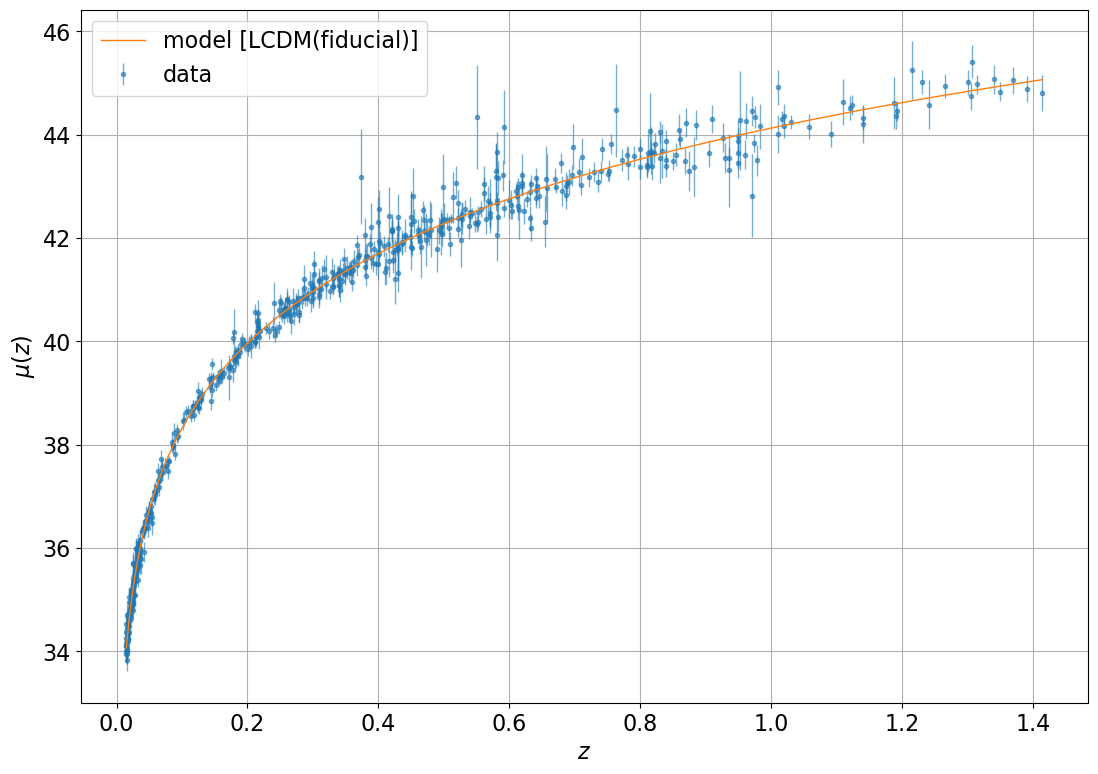

---

# Part 1 - Frequentist parameter inference

### Maximum Likelihood Estimation
As a starting point, let's try to estimate the best-fit parameters by maximizing the logarithm of the likelihood LL - or equivalently by minimizing the negative log likelihood, NLL. \
As seen, this has a couple issues:
- it is just a point estimate, and does not take into account the full shape of $\mathcal{L}(\boldsymbol{\theta};\boldsymbol{d})$
- it does not take into account the prior probabilities $p(\boldsymbol{\theta})$, considering de facto $p(\boldsymbol{\theta}|\boldsymbol{d})=p(\boldsymbol{d}|\boldsymbol{\theta})$

We work with a Gaussian Likelihood, describing our error model (we assume the data points to be normally distributed around their predicted values):

$$p(\boldsymbol{d}|\boldsymbol\theta) = {\cal L}(\boldsymbol{\theta}) = \prod_{i=1}^N \dfrac{1}{\sqrt{2\pi}\sigma_i}\exp\left[ -\dfrac{1}{2}\left( \dfrac{y_i-\mu(z_i, \boldsymbol{\theta})}{\sigma_i}\right)^2 \right]$$

where $\boldsymbol{d}_i=(\boldsymbol{z}_i, \boldsymbol{y}_i, \boldsymbol{\sigma}_i)$. The total likelihood is the product of the individual likelihoods $\cal{L}_i$, because we are assuming uncorrelated measurements both on the $x$ and the $y$ axis. $N$ indicates the number of data points (= 580).

We note that, since we're working with diagonal covariance and Gaussian likelihood, maximizing the LL is the same as finding the "least squares fit", i.e. minimizing the quantity

$$\chi^{2}=\sum_{i=1}^{N} \left( \frac{y_{i}-\mu\left(z_{i}, \boldsymbol{\theta}\right)}{\sigma_{i}} \right)^{2}.$$



---

### 1. Write down the Gaussian likelihood
Tip: it's also useful to define a negative_loglike and a chi2 function

### 2. Find $\theta_{MLE}$ by minimizing the NLL
Tip:  minimization routine $\tt {scipy.optimize.minimize}$ and the initial guess from above\
Are the best-fit values of the common parameters comparable for the different models?\
Note: the minization routine needs some initial guess and exploration ranges!



model: LCDM
theta_MLE: ['h', 'Om'] = [0.7000242  0.27761168]

model: wCDM
theta_MLE: ['h', 'Om', 'w0'] = [ 0.70018397  0.28116681 -1.00989912]


### 3. Compute frequentist confidence intervals
Since we have more than one parameter, we need the profile likelihood to compute confidence intervals.

As a warm-up, you can compute and plot the chi2 for each parameter, varying one while keeping the others fixed at theta_MLE.

For the profile likelihood, do the same but minimize the chi2 with respect to the other parameters at each step. The LCDM case will be easier, since we have maximise with respect to one parameter at a time. 


Compute the chi2 thresholds corresponding to the desired percentiles (we are working with 1 parameter, so dof=1, and we usually refer to the 68 and 95 percentiles)
Tip: `scipy.stats.chi2`, as any probability distribution, has the following useful methods: 
- `.pdf(x)` (or .pmf(k) for discrete): density/mass at a point.
- `.cdf(x)`: $P(X \le x)$, cumulative probability up to x.
- `.ppf(q)`: inverse CDF, i.e. value x such that cdf(x)=q  (quantile).
- `.rvs(size, random_state)`: random sampling from the distribution

delta_chi2_threshold(68%, 1 dof): 0.988946481478023
delta_chi2_threshold(95%, 1 dof): 3.8414588206941205



Now, compute delta_chi2 and find the intercepts with the levels corresponding to 1 and 2 sigma confidence intervals you just computed to get the values of the theta edges of the confidence intervals.
To be precise this would require an interpolation, but you can get a good enough estimate by looking at the grid point which minimizes the distance between the chi2 and the threshold.


LCDM
  h @ 0.70101
    68: [0.69697, 0.70303]
    95: [0.692929, 0.707071]
  Om @ 0.280808
    68: [0.256566, 0.29697]
    95: [0.240404, 0.313131]

wCDM
  h @ 0.70101
    68: [0.694949, 0.705051]
    95: [0.690909, 0.709091]
  Om @ 0.280808
    68: [nan, 0.345455]
    95: [nan, 0.393939]
  w0 @ -1.01414
    68: [-1.22424, -0.817172]
    95: [-1.44747, -0.764646]


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

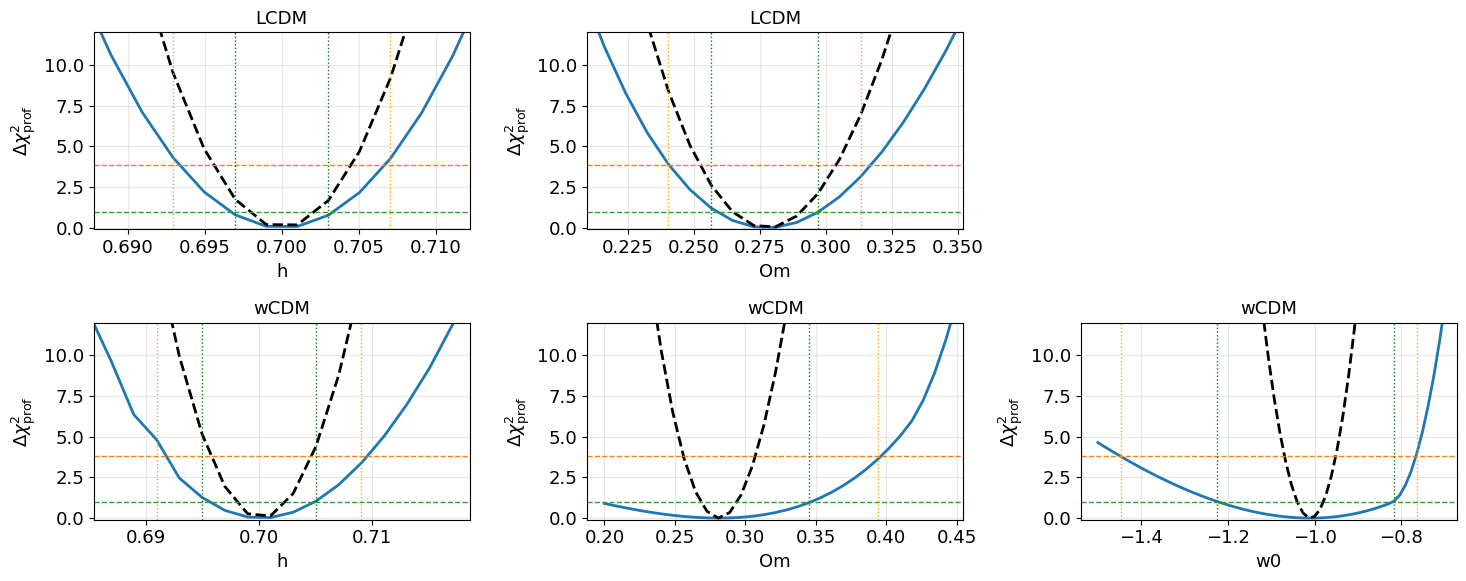

### 4. Compute GoF and p-values; check whether the models can be rejected at a given threshold (e.g., 5%)
This step is easier; recover the $\chi^2$ value at $\theta_{MLE}$ (you computed it before to get $\Delta\chi^2$) and compute the p-value from the CDF as
$$p = P(\chi^2 \geq  \chi^2_{min} | H_0) = \int^{\infty}_{\chi^2_{min}} \text {pdf}(\chi^2|H_0)\text d \chi^2 = 1-CDF(\chi^2_{min})$$
Remember: in this case $\chi^2_{min}$ follows a a $\chi^2_\nu$ distribution with $\nu = N_{data}-N_{params}$ degrees of freedom (dof).\
You can then test the null hypothesis (the model is true) against the alternative (the model is not true) by comparing the p-value with a threshold $\alpha$ (e.g., 0.05)

* if $p > \alpha$, $H_0$ is not rejected at $(1-\alpha)$ "confidence"
* if $p < \alpha$, $H_0$ is rejected at $(1-\alpha)$ "confidence"


LCDM
chi2:		 562.23
dof:		 578.00
chi2/dof:	 0.973
p-value = 0.673 > 0.05 - the null hypothesis (the LCDM model) cannot be rejected

wCDM
chi2:		 562.22
dof:		 577.00
chi2/dof:	 0.974
p-value = 0.662 > 0.05 - the null hypothesis (the wCDM model) cannot be rejected


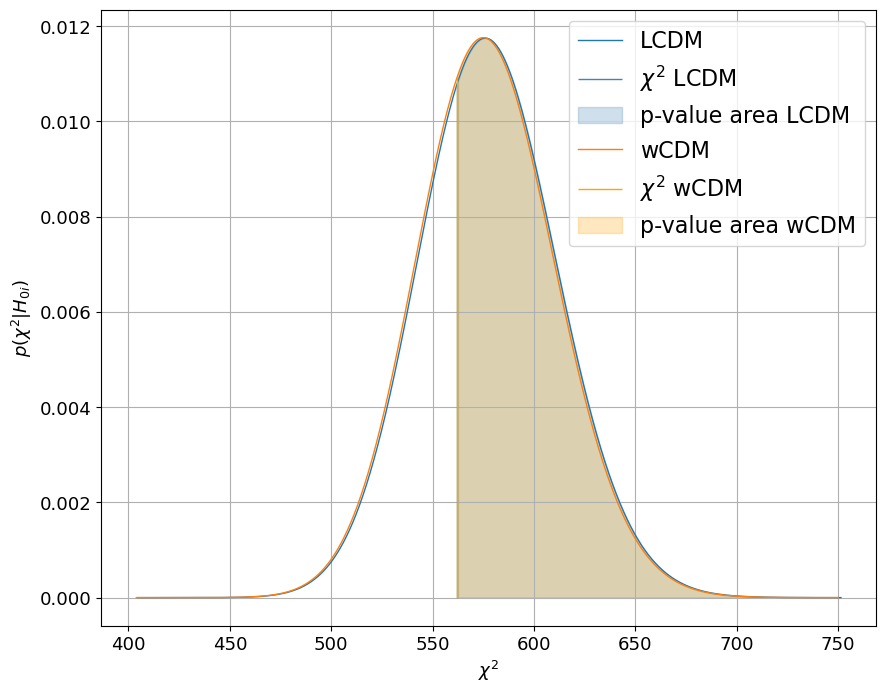

---

# Part 2 - Bayesian parameter inference

Now we turn to a Bayesian approach for parameter estimation and model selection; the posterior distribution of the parameters given the data is given by Bayes' theorem:

$$p(\boldsymbol\theta | \text {data}) = \dfrac{p(\text {data}|\boldsymbol\theta)p(\boldsymbol \theta)}   {p(\text{data})}  $$

This is what we need to sample.\ 
We will do it with the emcee and nautilus packages, which implement MH [on steroids] and the nested sampling algorithm respectively.


We use the $\tt {emcee}$ [link](https://emcee.readthedocs.io/en/stable/) Python package for the sampling process, with 2000 steps and 10 independent walkers starting from the best-fit values obtained by minimizing the NLL, with a small random deviation from such position for each walker. We discard the initial 10% of the points as burn-in

### 1. Define priors and posterior
This is required by emcee but not by Nautilus; remember that we defined the ln_likelihood, so it's convenient to define also the ln_prior. For the flat case, what is its expression? And for the Gaussian case? The (ln)posterior is trivial.\
Let's stert with flat and relatively broad priors, so as to be data-dominated.



### 2. Run emcee

For emcee, you can play with the number of steps and walkers, and the initial positions of the walkers (e.g., starting from the best-fit values obtained by minimizing the NLL, with a small random deviation from such position for each walker)


The run can be executed in parallel by doing (works on linux and macOS)

```
ctx = mp.get_context('fork')  # context manager for multiprocessing
with ctx.Pool(processes=n_cpu) as pool:
    sampler = emcee.EnsembleSampler(
        Nwalkers,
        ndim,
        ln_posterior,
        args=(data, _model),
        pool=pool,
    )
    sampler.run_mcmc(theta_0, Nsteps, progress=True)
```

100%|██████████| 2000/2000 [00:36<00:00, 54.07it/s]


Save chains if you want

### 3. Compute expectation values, standard deviations, parameter covariance and probability content of mean +/- std from the chains
* The first two steps are straightforward 
* For the third, you can use np.cov
* For the fourth, remember that once we have a chain we can integrate approximately by summing over the samples!
$$\int f(x) dx \approx \frac{1}{N} \sum_{i=1}^{N} f(x_i)$$
Bonus: you can also compute the intervals containing a given percentage of the probability (e.g., 68 and 95 percentiles) by looking at the quantiles of the distribution of the samples in the chain (use np.quantile)


--------------------- LCDM -------------------------------------

68.0% central interval: [0.696715, 0.703446]
68.0% central interval: [0.258691, 0.296527]
h: 0.70014 +/- 0.00339 at prob = 0.68437
Om: 0.27776 +/- 0.01948 at prob = 0.69506

--------------------- wCDM -------------------------------------

68.0% central interval: [0.695083, 0.704891]
68.0% central interval: [0.188021, 0.343352]
68.0% central interval: [-1.207, -0.807168]
h: 0.69995 +/- 0.00482 at prob = 0.67188
Om: 0.26608 +/- 0.07941 at prob = 0.69331
w0: -1.00689 +/- 0.20001 at prob = 0.68025


### 4. Produce a trace plot and check that the chains don't have pathological behaviour.
Removing a burn-in phase should not be necessary, as we are starting from theta_MLE. You can check what happens if you start from a different position.\
Overplot the previously computed best-fit values and credible intervals to check that they are consistent with the chain distribution.

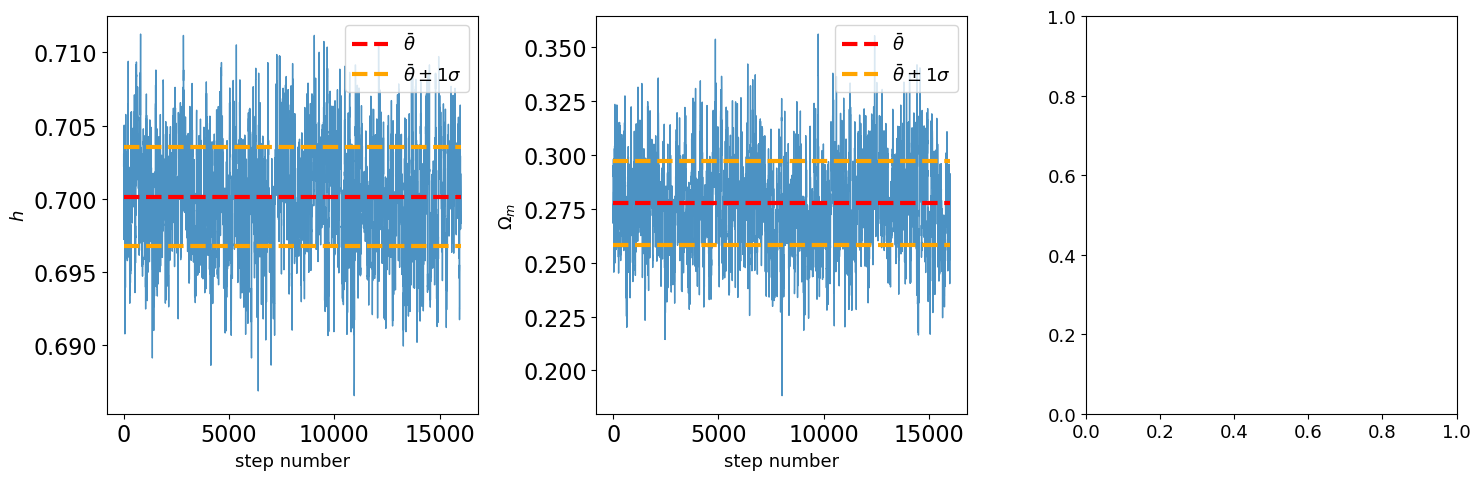

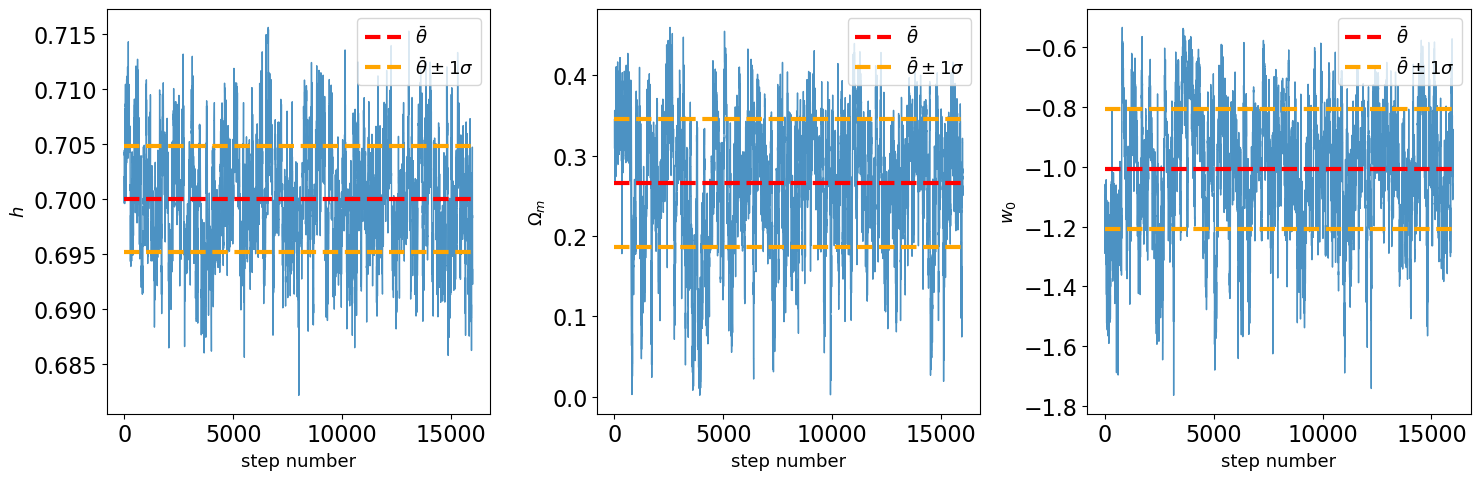

### 5. Make a corner plot with `corner`
This package is a bit old, but it's still widely used and does the at showing things the way they are, without smoothing
You can overplot the best-fit values from the MLE to check the consistency of the two approaches

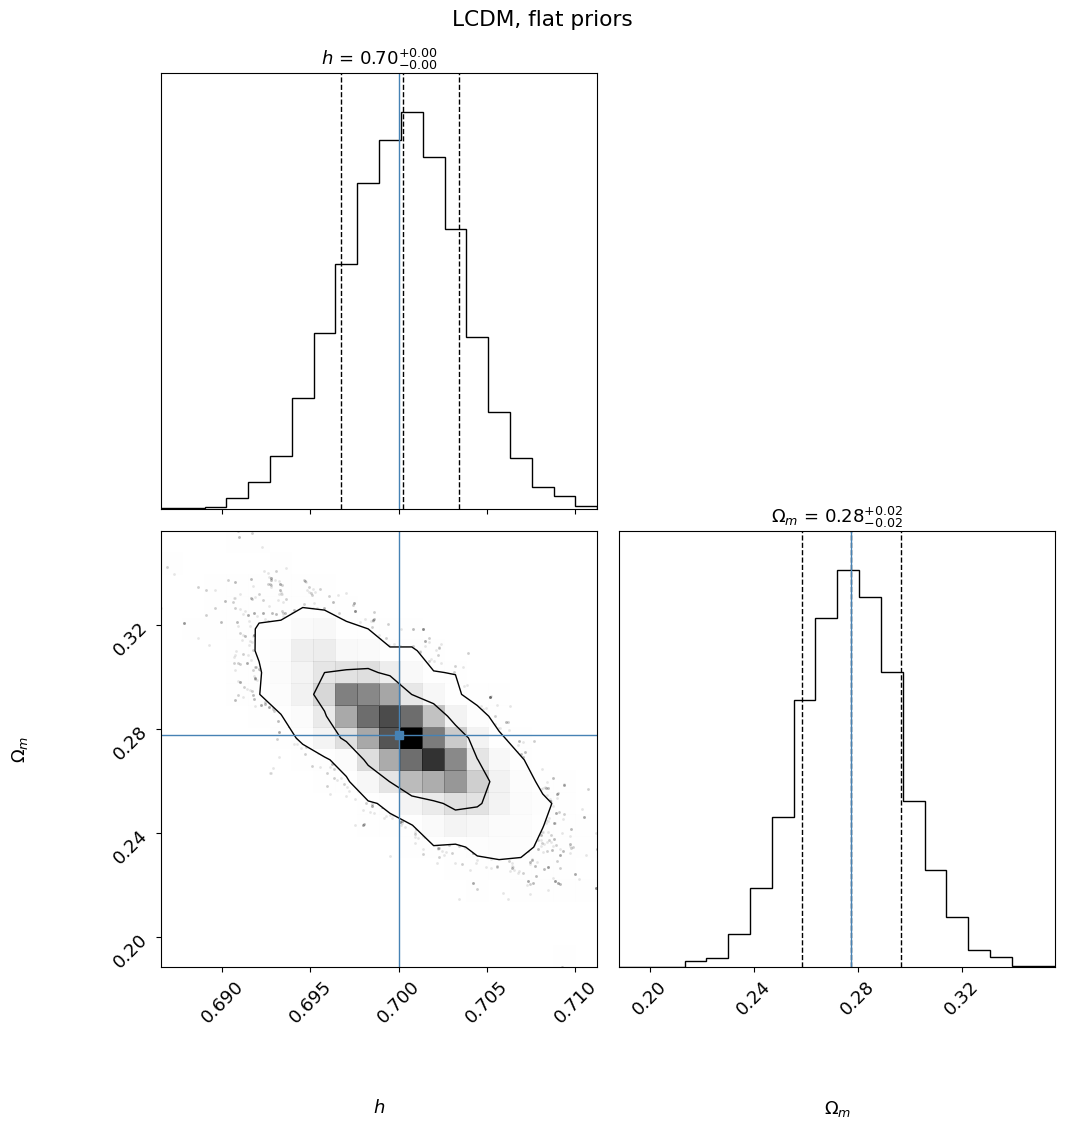

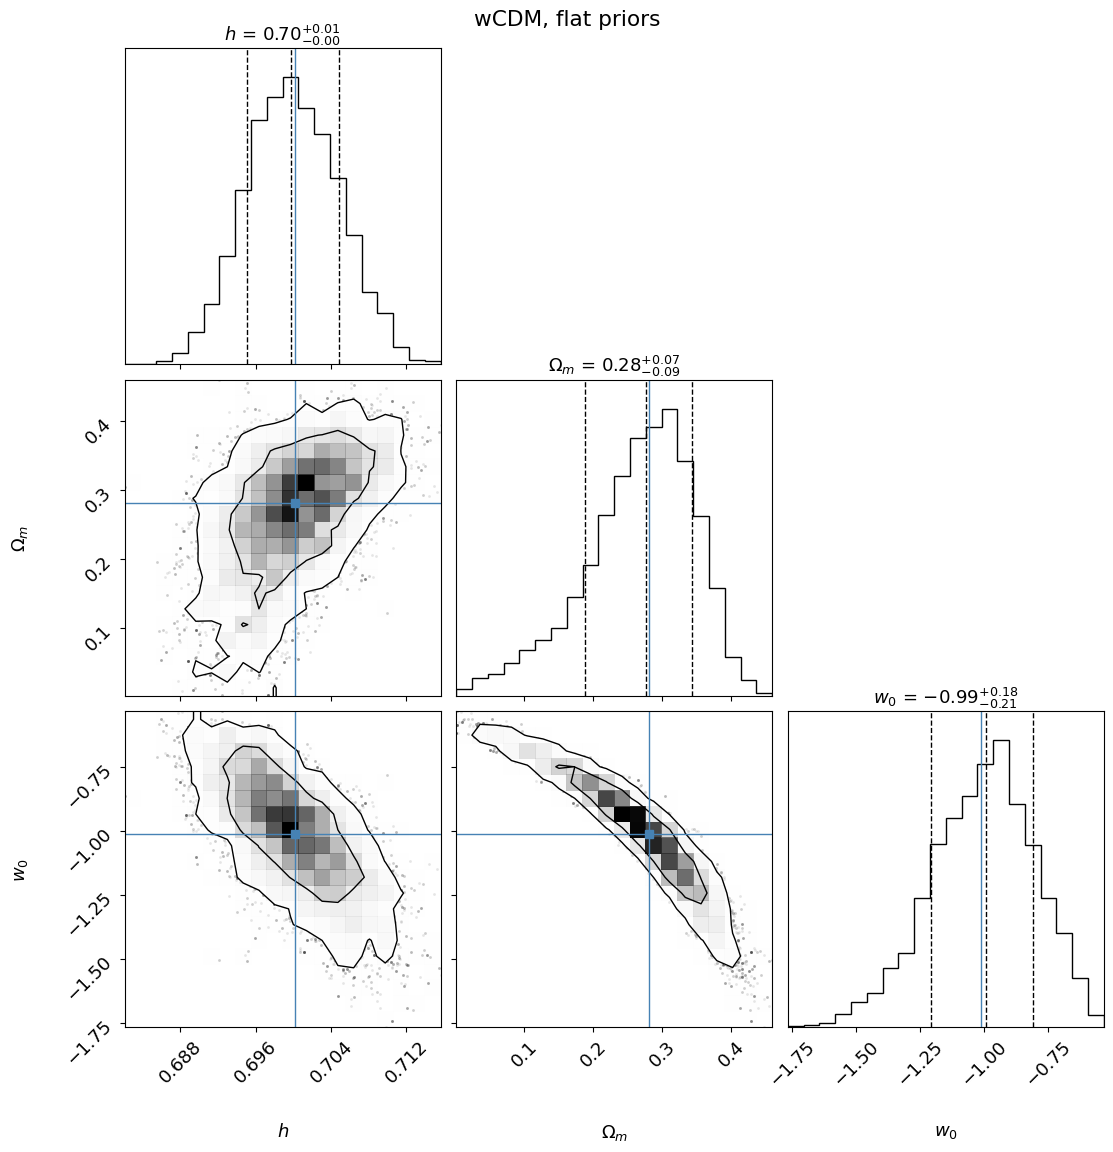

### 6. Make a corner plot with `getdist`
This is a more modern package, which also allows to smooth the contours with KDEs. You can overplot the best-fit values from the MLE to check the consistency of the two approaches


Removed no burn in
Removed no burn in


Text(0.5, 0.98, 'LCDM vs wCDM, flat priors')

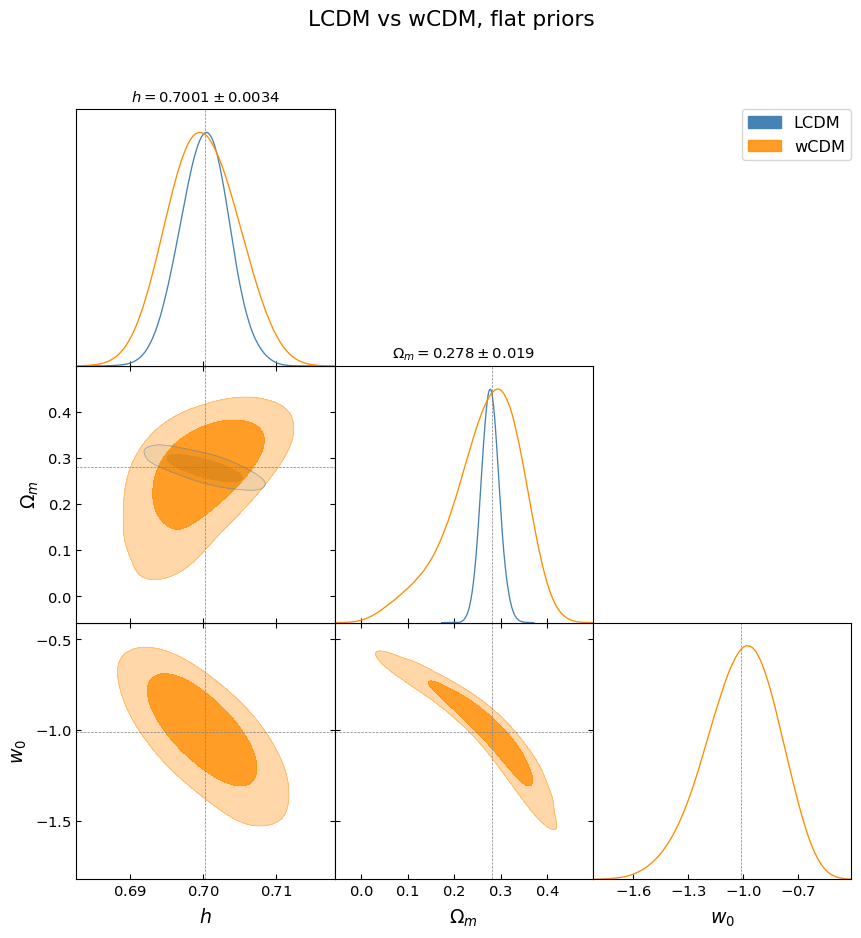

### 7. Plot best-fit curves and residuals
No appreciable difference between the two models, plot just LCDM. This simply to visually inspect the bes-fit line and to check whether the residuals show any unwanted trend.

/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_58323/59516870.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(prop={'size': 16})
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_58323/59516870.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend(prop={'size': 16})


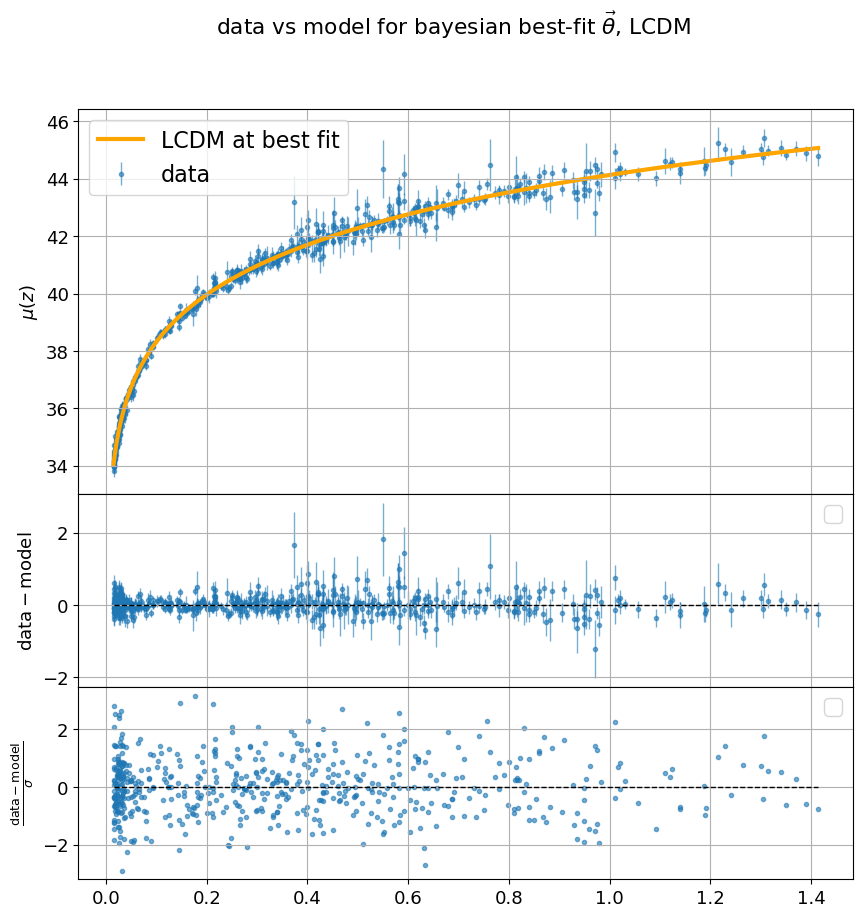

# Part 3 - Bayesian model selection
In order to select the best model we compute the odds ratio

$$O_{12} = \dfrac{p(M_1|\text{data})}{p(M_2|\text{data})}=\dfrac{p(\text{data}|M_1)P(M_1)}{p(\text{data}|M_2)P(M_2)}=\dfrac{\int p(\text{data}|M_1,\boldsymbol\theta_1)p(\boldsymbol\theta_1|M_1)\text{d}\boldsymbol\theta_1}{\int p(\text{data}|M_2,\boldsymbol\theta_2)p(\boldsymbol\theta_2|M_2)\text{d}\boldsymbol\theta_2}\dfrac{p(M_1)}{p(M_2)}$$

which is simply the ratio of the posterior distributions, marginalized over the parameters of the models, folded with the prior probabilities on the different models (which we consider equal to each other).

### 1. Perform nested sampling with nautilus
Use the Nautilus ([link](https://nautilus-sampler.readthedocs.io/en/latest/)) package to perform nested sampling and compute the evidence for the two models\
you might have to define a wrapper function around the likelihood, as it requires the argument to be a dictionary of parameters, and not a list or array as in emcee.\
The evidence is given by the `results['logZ']` attribute of the output of the `nautilus.run_nested` function.\
You can try using 2000 live points
Again, use the context manager for multiprocessing to speed up the run
```
with ctx.Pool(processes=n_cpu) as pool:
    sampler_nautilus_wCDM = Sampler(
        prior: Prior,
        likelihood: (params: Any, model: Any) -> Any,
        n_dim: Any | None = None,
        n_live: int = 2000,
        likelihood_kwargs=...,
        n_live=n_live,
        pool=pool,
    )
```

Define flat priors and likelihood\
We use the same flat priors adopted above with `emcee` for a fair comparison. You can instantiate flat priors with
```
from nautilus import Prior
prior = Prior()
prior.add_parameter(
        param_name, dist=(prior_ranges[param_name][0], prior_ranges[param_name][1])
    )
    ...
```

Sample LCDM

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 17     | 1        | 4        | 35640    | N/A    | 10841 | +111.49  
nautilus LCDM took 37.0 seconds to run
LCDM: logZ = 111.488, n_eff = 10841.0


Sample wCDM


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 19     | 1        | 4        | 40500    | N/A    | 13022 | +110.11  
nautilus wCDM took 54.9 seconds to run
wCDM: logZ = 110.111, n_eff = 13021.9


### 2. Plot the results with getdist
Now use the getdist package to plot the results of our runs. getdist performs internally a Gaussian smoothing of the histograms of the samples, as well as computing the best-fit and confidence intervals ()

Removed no burn in
Removed no burn in


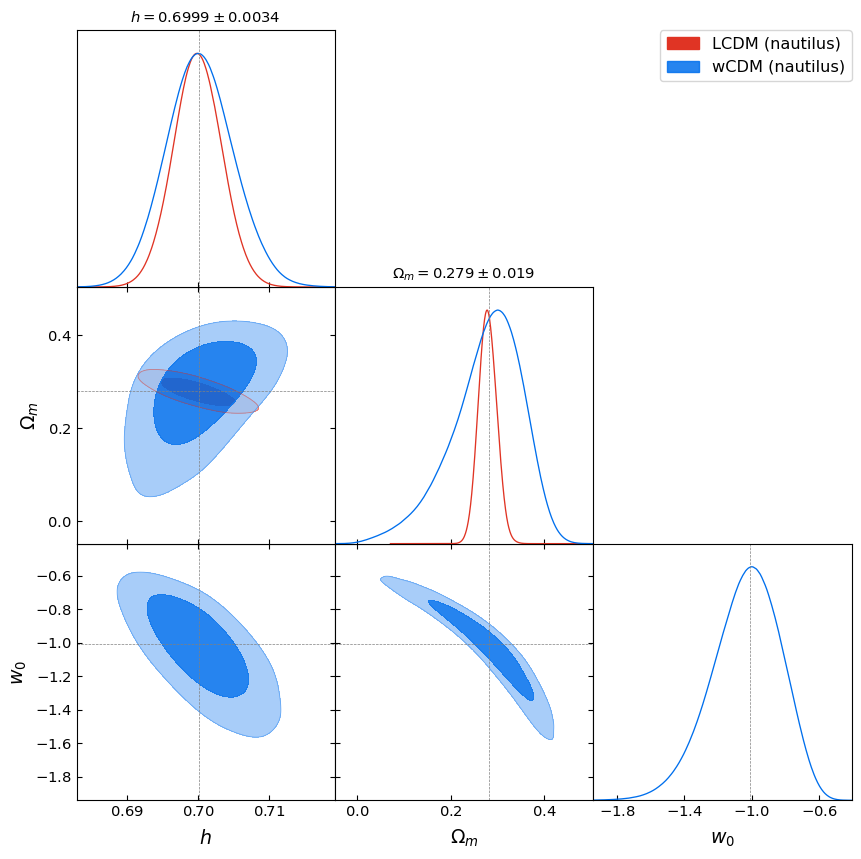

Compare nautilus to emcee with getdist

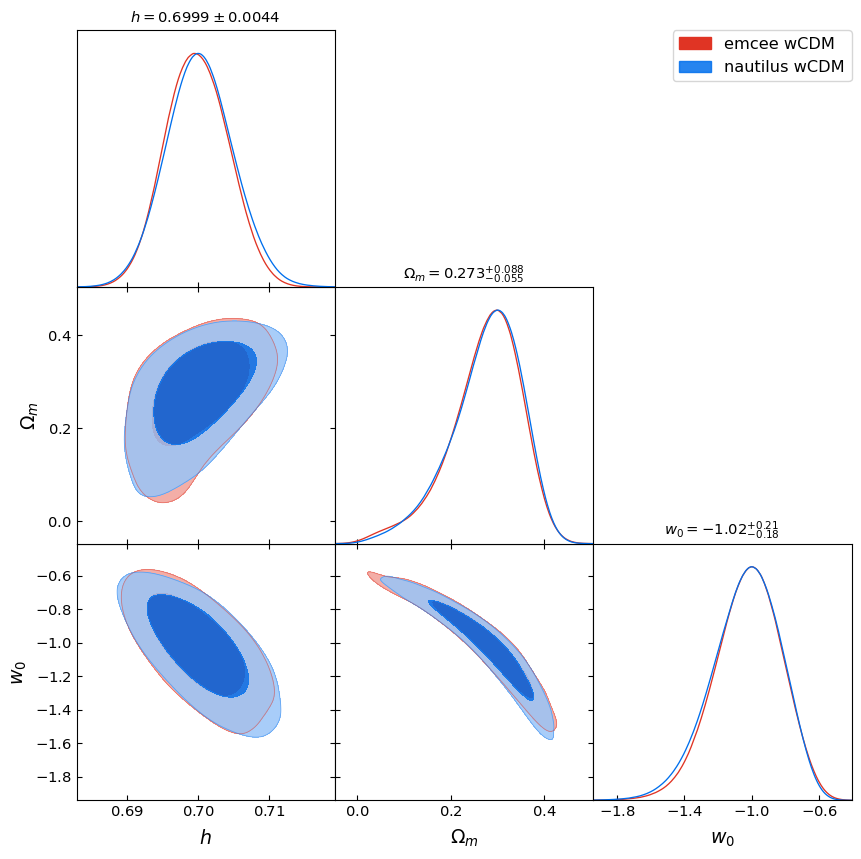

### 3. Compute Bayes factors for Bayesian model comparison
Now, perform a model comparison between LCDM and wCDM by computing the odds ratio $O_{12}$, which is the ratio of the evidences of the two models. 

Retrieve the logZ values for the different models from the Nautilus runs

Compare them as explained and quantify the strength of efidence using the Jeffrey's scale

logZ_LCDM = 111.488
logZ_wCDM = 110.111
log Bayes factor (LCDM / wCDM) = 1.377
Preferred model: LCDM
Evidence strength: weak


Compute the Savage-Dickey density ratio and check whether the results match

Savage-Dickey B(LCDM / wCDM) = 3.918
Savage-Dickey logB(LCDM / wCDM) = 1.366
ΔlogB (Savage-Dickey - evidence) = -0.012


Try rerunning playing around with the priors (shape/ranges) and see if the results change

# Part 4 - Fisher-matrix forecasts

### 1. Compute numerical derivatives using different methods
Set theta_fid to the best-fit values of the `nautilus` (or `emcee`) runs, to be able to compare with the MCMC results\
Compute the model prediction at theta_fid, and then compute the numerical derivatives with respect to each parameter by varying one parameter at a time, keeping the others fixed at their fiducial values.\
Try different methods to compute the numerical derivatives, e.g. three- and five-point stencils, and check the stability for different step sizes.\

### 2. Compute Fisher matrix with a diagonal covariance

### 3. Plot the results with getdist and compare against MCMC

Removed no burn in
Removed no burn in


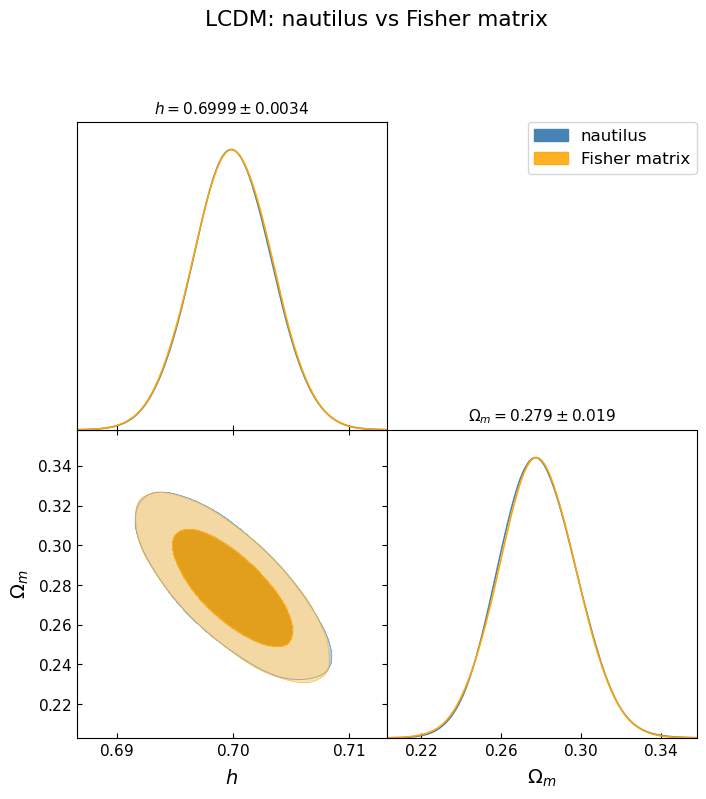

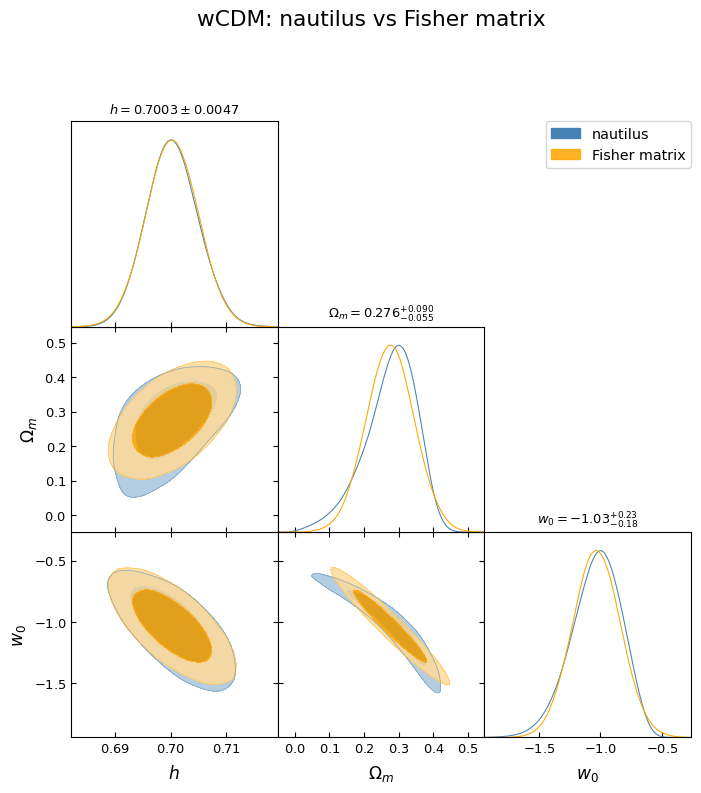